# Hotel Booking Demand Analysis

## Project Overview

This project analyzes hotel booking data to identify patterns in cancellations, booking behavior, seasonality, and pricing.

The analysis focuses on answering business-oriented questions using Python, Pandas, and NumPy, followed by visualizations of the most relevant findings.

### Main Areas of Analysis
- Booking cancellations and cancellation drivers
- Booking lead time
- Seasonality and booking volume
- ADR (Average Daily Rate) patterns
- Guest behavior and special requests
- Market segments and booking characteristics

## Data Loading and Initial Exploration

In [124]:
import numpy as np
import pandas as pd

In [125]:
bookings = pd.read_csv(r"\hotel_bookings.csv")

In [126]:
bookings.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [127]:
bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [128]:
bookings.describe().round(2)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.1,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.4,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.0,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00


In [129]:
bookings.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [130]:
bookings.shape

(119390, 32)

### Data Cleaning and Preparation

In [131]:
bookings.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [133]:
bookings.isna().mean().mul(100).round(2) 

hotel                              0.00
is_canceled                        0.00
lead_time                          0.00
arrival_date_year                  0.00
arrival_date_month                 0.00
arrival_date_week_number           0.00
arrival_date_day_of_month          0.00
stays_in_weekend_nights            0.00
stays_in_week_nights               0.00
adults                             0.00
children                           0.00
babies                             0.00
meal                               0.00
country                            0.41
market_segment                     0.00
distribution_channel               0.00
is_repeated_guest                  0.00
previous_cancellations             0.00
previous_bookings_not_canceled     0.00
reserved_room_type                 0.00
assigned_room_type                 0.00
booking_changes                    0.00
deposit_type                       0.00
agent                             13.69
company                           94.31


In [134]:
bookings["children"] = bookings["children"].fillna(0)
bookings["country"] = bookings["country"].fillna("Unknown")

In [135]:
bookings.duplicated().sum()

np.int64(31994)

In [136]:
bookings.loc[bookings.duplicated()].head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
219,Resort Hotel,1,1,2015,July,28,8,0,1,2,...,No Deposit,NaN,110.0,0,Transient,104.72,0,1,Canceled,2015-07-08
256,Resort Hotel,0,91,2015,July,28,10,0,2,2,...,No Deposit,240.0,NaN,0,Transient,73.80,0,1,Check-Out,2015-07-12
261,Resort Hotel,0,30,2015,July,28,10,2,2,2,...,No Deposit,NaN,NaN,0,Transient-Party,197.00,0,1,Check-Out,2015-07-14
353,Resort Hotel,0,98,2015,July,29,13,1,1,2,...,No Deposit,240.0,NaN,0,Transient-Party,82.00,0,3,Check-Out,2015-07-15
372,Resort Hotel,0,40,2015,July,29,13,1,4,2,...,No Deposit,250.0,NaN,0,Transient,120.00,0,2,Check-Out,2015-07-18


Duplicate records: 31,994 fully duplicated rows were identified. 
However, the dataset does not contain a unique booking identifier, 
so identical rows may represent separate bookings with the same characteristics. 
Therefore, duplicates were retained to avoid removing potentially valid observations.

In [138]:
mask_no_guest = (bookings["adults"] == 0) & (bookings["children"] == 0) & (bookings["babies"] == 0)
mask_no_adults = (bookings["adults"] == 0) & ((bookings["children"] > 0) | (bookings["babies"] > 0))

mask_no_guest.sum() + mask_no_adults.sum()

Bookings with no guests: 180
Bookings with no adults: 223


In [139]:
bookings = bookings.loc[~mask_no_guest]

In [140]:
bookings.shape

(119210, 32)

180 bookings contained no guests (0 adults, 0 children, and 0 babies).
These records were removed because they do not represent valid guest bookings.
Bookings without adults but with children/babies were retained,
as there is not enough information to classify them as invalid.

In [300]:
bookings[["stays_in_weekend_nights", "stays_in_week_nights"]].describe().round(2)

,stays_in_weekend_nights,stays_in_week_nights
count,119210.00,119210.0
mean,0.93,2.5
std,1.00,1.9
min,0.00,0.0
25%,0.00,1.0
50%,1.00,2.0
75%,2.00,3.0
max,19.00,50.0


In [144]:
mask_no_nights = (bookings["stays_in_weekend_nights"] == 0) & (bookings["stays_in_week_nights"] == 0)

mask_no_nights.sum()

np.int64(645)

In [145]:
bookings.loc[mask_no_nights, "is_canceled"].value_count()

is_canceled
0    622
1     23
Name: count, dtype: int64

In [146]:
bookings.loc[mask_no_nights, "reservation_status"].value_counts()

reservation_status
Check-Out    622
No-Show       13
Canceled      10
Name: count, dtype: int64

645 bookings have zero recorded nights.
Most of them (622) have a Check-Out status, suggesting they may represent valid records.
Therefore, zero-night bookings were retained rather than treated as invalid observations.

In [148]:
bookings["adr"].describe().round(2)

count    119210.00
mean        101.97
std          50.43
min          -6.38
25%          69.50
50%          94.95
75%         126.00
max        5400.00
Name: adr, dtype: float64

In [149]:
mask_negative_adr = (bookings["adr"] < 0) 

mask_negative_adr.sum()

np.int64(1)

In [150]:
bookings.loc[mask_negative_adr]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,No Deposit,273.0,NaN,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


One booking has a negative ADR (-6.38).
The remaining booking information appears valid and the reservation has a Check-Out status.
Since the reason for the negative value cannot be determined from the dataset,
the record was retained and treated as a potential anomaly.

In [152]:
mask_highest_adr = (bookings["adr"] == 5400) 

bookings.loc[mask_highest_adr]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
48515,City Hotel,1,35,2016,March,13,25,0,1,2,...,Non Refund,12.0,NaN,0,Transient,5400.0,0,0,Canceled,2016-02-19


In [153]:
bookings["adr"].nlargest(10)

48515     5400.00
111403     510.00
15083      508.00
103912     451.50
13142      450.00
13391      437.00
39155      426.25
39568      402.00
39118      397.38
13323      392.00
Name: adr, dtype: float64

ADR outlier: The maximum ADR of 5,400 is substantially higher than the next highest observations. Since there is not enough information to determine whether the value is erroneous, the record was retained. Median ADR is used in subsequent pricing analysis to reduce the influence of this extreme value.

In [154]:
bookings["arrival_date_month"] =  pd.to_datetime(bookings["arrival_date_month"], format="%B").dt.month 


In [155]:
bookings["arrival_date"] = pd.to_datetime(
    {
    "year": bookings["arrival_date_year"],
    "month": bookings["arrival_date_month"],
    "day": bookings["arrival_date_day_of_month"]
    })

bookings["arrival_date"].head()

0   2015-07-01
1   2015-07-01
2   2015-07-01
3   2015-07-01
4   2015-07-01
Name: arrival_date, dtype: datetime64[ns]

In [157]:
bookings["reservation_status_date"] = pd.to_datetime(
    bookings["reservation_status_date"])

In [158]:
bookings["reservation_status_date"].dtype

dtype('<M8[ns]')

In [161]:
bookings["total_nights"] = bookings["stays_in_weekend_nights"] + bookings["stays_in_week_nights"]

bookings["total_nights"].describe().round(2)

count    119210.00
mean          3.43
std           2.54
min           0.00
25%           2.00
50%           3.00
75%           4.00
max          69.00
Name: total_nights, dtype: float64

In [162]:
bookings["total_guests"] = bookings["adults"] + bookings["children"] + bookings["babies"]

bookings["total_guests"].describe().round(2)

count    119210.00
mean          1.97
std           0.72
min           1.00
25%           2.00
50%           2.00
75%           2.00
max          55.00
Name: total_guests, dtype: float64

In [163]:
bookings["total_guests"].nlargest(10)

2173    55.0
1643    50.0
1539    40.0
1917    27.0
1962    27.0
1587    26.0
1752    26.0
1884    26.0
2003    26.0
2164    26.0
Name: total_guests, dtype: float64

In [184]:
bookings[["total_guests", "customer_type"]].sort_values(by="total_guests",ascending=False).head(10)

,total_guests,customer_type
2173,55.0,Group
1643,50.0,Group
1539,40.0,Group
1962,27.0,Group
1917,27.0,Group
1587,26.0,Group
1884,26.0,Group
2003,26.0,Group
1752,26.0,Group
2164,26.0,Group


The largest bookings (up to 55 guests) were reviewed as potential outliers.
The 10 bookings with the highest guest counts were all classified as Group.
Therefore, these observations were retained as valid group bookings.

In [186]:
bookings["lead_time"].describe().round(2)

count    119210.00
mean        104.11
std         106.88
min           0.00
25%          18.00
50%          69.00
75%         161.00
max         737.00
Name: lead_time, dtype: float64

## Exploratory Data Analysis

### 1. What is the overall cancellation rate?

In [190]:
(bookings["is_canceled"].mean()*100).round(2)

np.float64(37.08)

**Insight:** 37.08% of all bookings were canceled.

### 2. Does the cancellation rate differ between City Hotel and Resort Hotel?

In [197]:
(bookings.groupby("hotel")["is_canceled"].mean()*100).round(2)

hotel
City Hotel      41.79
Resort Hotel    27.77
Name: is_canceled, dtype: float64

**Insight:** City Hotel has a substantially higher cancellation rate than Resort Hotel
(approximately 42% vs. 28%).

### 3. How does lead time relate to the likelihood of cancellation?

In [201]:
bookings["lead_time_group"] = pd.cut(
    bookings["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, float("inf")],
    labels=["0-7", "8-30", "31-90", "91-180", "181-365", "366+"]
)

In [264]:
cancellation_by_lead_time = (bookings.groupby("lead_time_group", observed=True)["is_canceled"].mean() * 100).round(2)
cancellation_by_lead_time

lead_time_group
0-7         9.60
8-30       27.89
31-90      37.73
91-180     44.74
181-365    55.46
366+       67.65
Name: is_canceled, dtype: float64

**Insight:** The cancellation rate increases substantially with lead time. Only 9.60% of bookings made up to 7 days in advance were canceled, compared with 67.65% of bookings made more than a year in advance.

### 4. How does booking volume vary by month?

In [292]:
bookings_by_month = bookings["arrival_date_month"].value_counts().sort_index()

bookings_by_month

arrival_date_month
1      5921
2      8052
3      9768
4     11078
5     11780
6     10929
7     12644
8     13861
9     10500
10    11147
11     6771
12     6759
Name: count, dtype: int64

**Insight:** Booking volume shows a seasonal pattern. August had the highest number of bookings (13,861), followed by July (12,644), while January had the lowest booking volume (5,921).

### 5. Does the cancellation rate vary by month?

In [291]:
(bookings.groupby("arrival_date_month")["is_canceled"].mean() * 100).round(2)



arrival_date_month
1     30.50
2     33.45
3     32.23
4     40.78
5     39.70
6     41.49
7     37.46
8     37.78
9     39.19
10    38.09
11    31.31
12    35.03
Name: is_canceled, dtype: float64

**Insight:** Cancellation rates vary throughout the year. June had the highest cancellation rate (41.49%), while January had the lowest (30.50%). Unlike lead time, however, there is no clear month-to-month trend.

### 6. How does median ADR differ between City Hotel and Resort Hotel?

In [209]:
bookings.groupby("hotel")["adr"].median().round(2)

hotel
City Hotel      99.96
Resort Hotel    75.00
Name: adr, dtype: float64

**Insight:** City Hotel has a higher median ADR than Resort Hotel (99.96 vs. 75.00), indicating that a typical booking at City Hotel has a higher daily rate.

### 7. How does ADR vary by month for each hotel type?

In [272]:
adr_by_month_hotel = (bookings.groupby(["hotel","arrival_date_month"])["adr"].median().round(2).unstack("hotel"))

adr_by_month_hotel

hotel,City Hotel,Resort Hotel
arrival_date_month,,
1,80.00,47.72
2,80.00,51.00
3,88.00,55.62
4,105.00,75.00
5,120.00,73.00
6,117.85,105.00
7,107.10,152.50
8,109.00,188.42
9,107.00,86.00


**Insight:** ADR shows a strong seasonal pattern, particularly for Resort Hotel. 
Its median ADR rises sharply during the summer, reaching 188.42 in August, 
while City Hotel rates remain relatively more stable throughout the year.

### 8. Do repeated guests cancel less often than new guests?

In [224]:
(bookings.groupby("is_repeated_guest")["is_canceled"].mean()*100).round(2)

is_repeated_guest
0    37.81
1    14.65
Name: is_canceled, dtype: float64

**Insight:** Repeated guests have a substantially lower cancellation rate than new guests (14.65% vs. 37.81%), showing a strong association between repeat-guest status and lower cancellation rates.epeated guests have a substantially lower cancellation rate than new guests (14.65% vs. 37.81%), suggesting that returning guests are more likely to keep their reservations.

### 9. Are bookings with more special requests less likely to be canceled?

In [228]:
bookings["total_of_special_requests"].value_counts()

total_of_special_requests
0    70201
1    33183
2    12952
3     2494
4      340
5       40
Name: count, dtype: int64

In [294]:
cancellation_by_special_requests = (bookings.groupby("total_of_special_requests")["is_canceled"].mean()*100).round(2)

cancellation_by_special_requests

total_of_special_requests
0    47.77
1    22.05
2    22.13
3    17.84
4    10.59
5     5.00
Name: is_canceled, dtype: float64

**Insight:** Bookings with at least one special request have a substantially lower cancellation rate than bookings with no special requests. Overall, cancellation rates tend to decrease as the number of special requests increases, although bookings with 4–5 requests are relatively rare and should be interpreted with caution.

### 10. Do longer stays have higher cancellation rates?

In [230]:
bookings["total_nights"].value_counts().sort_index()

total_nights
0       645
1     21005
2     27632
3     27064
4     17373
5      7771
6      3846
7      8648
8      1155
9       840
10     1135
11      393
12      220
13      141
14      913
15       72
16       40
17       20
18       35
19       22
20       14
21       71
22       13
23        8
24        6
25       37
26        6
27        4
28       34
29       13
30       13
33        3
34        1
35        5
38        1
42        4
45        1
46        1
48        1
56        2
60        1
69        1
Name: count, dtype: int64

In [238]:
bookings["total_nights_group"] = pd.cut(
    bookings["total_nights"],
    bins=[-1, 0, 2, 4, 7, 14, float("inf")],
    labels=["0","1-2","3-4","5-7","8-14","15+"]
)

In [240]:
bookings["total_nights_group"].value_counts()

total_nights_group
1-2     48637
3-4     44437
5-7     20265
8-14     4797
0         645
15+       429
Name: count, dtype: int64

In [241]:
(bookings.groupby("total_nights_group", observed=True)["is_canceled"].mean() * 100).round(2)

total_nights_group
0        3.57
1-2     35.84
3-4     39.84
5-7     35.34
8-14    34.10
15+     56.41
Name: is_canceled, dtype: float64

**Insight:** Cancellation rates are relatively similar for stays between 1 and 14 nights, ranging from 34.10% to 39.84%. Bookings of 15 nights or more have a notably higher cancellation rate (56.41%), although this group contains relatively few observations. Zero-night bookings represent a distinct group and should be interpreted separately.

### 11. Which market segments have the highest cancellation rates?

In [244]:
bookings["market_segment"].value_counts().sort_index()

market_segment
Aviation           235
Complementary      728
Corporate         5282
Direct           12582
Groups           19791
Offline TA/TO    24182
Online TA        56408
Undefined            2
Name: count, dtype: int64

In [246]:
(bookings.groupby("market_segment")["is_canceled"].mean() * 100).round(2).sort_values(ascending=False)

market_segment
Undefined        100.00
Groups            61.11
Online TA         36.76
Offline TA/TO     34.33
Aviation          22.13
Corporate         18.76
Direct            15.37
Complementary     12.23
Name: is_canceled, dtype: float64

**Insight:** Group bookings have the highest meaningful cancellation rate (61.11%), substantially exceeding other major market segments. Direct bookings have a much lower cancellation rate (15.37%). The Undefined segment shows a 100% cancellation rate, but it contains only two bookings and is therefore not considered meaningful for interpretation.

### 12. Does receiving a different room than originally reserved relate to cancellations?

In [247]:
bookings["room_changed"] = bookings["reserved_room_type"] != bookings["assigned_room_type"]

In [256]:
bookings["room_changed"].agg(
    {"total_bookings": "count",
    "room_change_rate": lambda x: (x.mean()*100).round(2)}
)

total_bookings      119210.00
room_change_rate        12.41
Name: room_changed, dtype: float64

**Observation:** 12.41% of bookings were assigned a different room type than originally reserved.

In [258]:
(bookings.groupby("room_changed")["is_canceled"].mean() * 100).round(2)

room_changed
False    41.56
True      5.41
Name: is_canceled, dtype: float64

**Insight:** Bookings with a different assigned room type had a substantially lower cancellation rate than bookings where the reserved and assigned room types matched (5.41% vs. 41.56%). However, this relationship should not be interpreted as causal, as room assignment may occur at a later stage of the booking process.

### 13. Does requiring a parking space relate to cancellation rates?

In [259]:
bookings["required_car_parking_spaces"].value_counts()

required_car_parking_spaces
0    111801
1      7376
2        28
3         3
8         2
Name: count, dtype: int64

In [261]:
bookings["parking_required"] = bookings["required_car_parking_spaces"] > 0

In [262]:
(bookings.groupby("parking_required")["is_canceled"].mean() * 100).round(2)

parking_required
False    39.53
True      0.00
Name: is_canceled, dtype: float64

**Insight:** None of the bookings requiring at least one parking space were canceled, compared with a 39.53% cancellation rate among bookings without a parking requirement. This indicates a strong association between parking requirements and completed bookings, although the relationship should not be interpreted as causal.

## Data Visualization

### The following visualizations highlight the key patterns identified during the exploratory analysis.

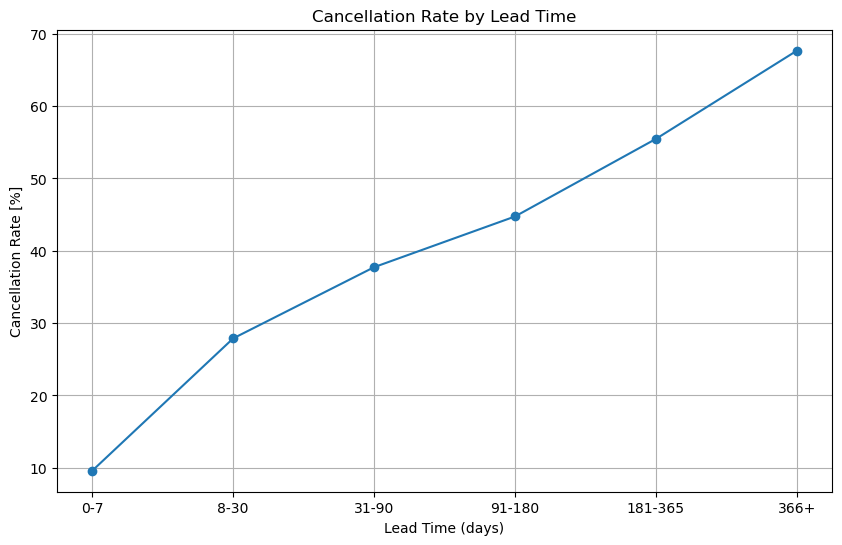

In [295]:
cancellation_by_lead_time.plot(
    marker = "o",
    title = "Cancellation Rate by Lead Time",
    xlabel = "Lead Time (days)",
    ylabel = "Cancellation Rate [%]",
    figsize = (10, 6),
    grid = True
);

**Insight:** The cancellation rate increases consistently with booking lead time, from 9.60% for bookings made 0–7 days in advance to 67.65% for bookings made more than 365 days in advance. This shows a strong association between longer booking lead times and higher cancellation rates.

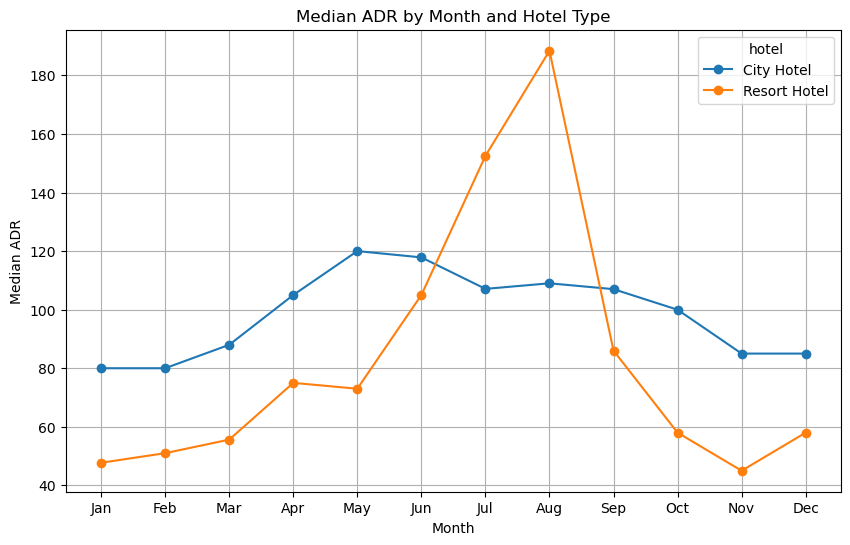

In [302]:
ax = adr_by_month_hotel.plot(
    marker="o",
    title="Median ADR by Month and Hotel Type",
    xlabel="Month",
    ylabel="Median ADR",
    figsize=(10, 6),
    grid=True
)

ax.set_xticks(range(1, 13))
ax.set_xticklabels([
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]);

**Insight:** Resort Hotel shows strong seasonal variation in ADR, with the median rate peaking at 188.42 in August. In contrast, City Hotel rates remain more stable throughout the year, reaching their highest median ADR of 120.00 in May.

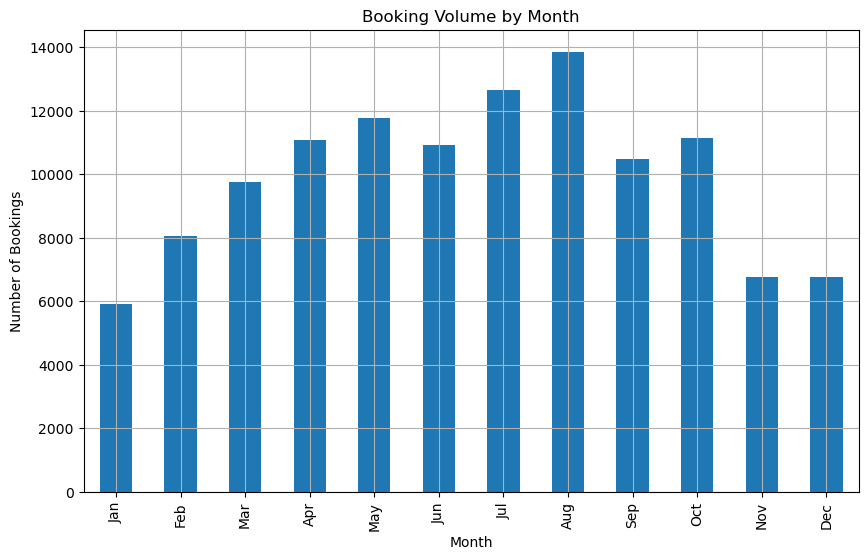

In [293]:
ax = bookings_by_month.plot(
    title="Booking Volume by Month",
    xlabel="Month",
    ylabel="Number of Bookings",
    figsize=(10, 6),
    grid=True,
    kind = "bar"
);

ax.set_xticks(range(12))
ax.set_xticklabels([
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]);

**Insight:** Booking volume shows clear seasonality, with the highest number of bookings in August (13,861) and July (12,644). January recorded the lowest booking volume (5,921).

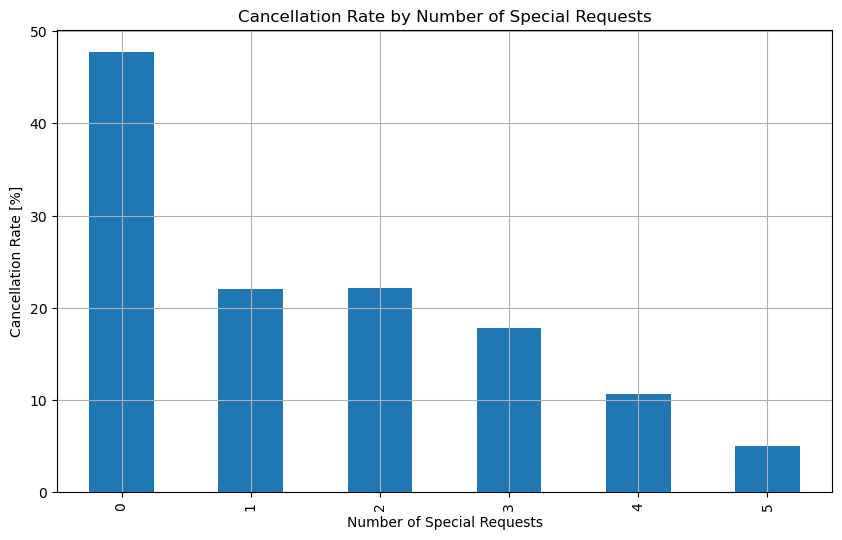

In [301]:
cancellation_by_special_requests.plot(
    title="Cancellation Rate by Number of Special Requests",
    xlabel="Number of Special Requests",
    ylabel="Cancellation Rate [%]",
    figsize=(10, 6),
    grid=True,
    kind = "bar",
    
);

**Insight:** Bookings with at least one special request have a substantially lower cancellation rate than bookings with no special requests. Overall, cancellation rates tend to decrease as the number of special requests increases, although bookings with 4-5 requests are relatively rare and should be interpreted with caution.

## Key Insights and Conclusions

- **Cancellation behavior:** 37.08% of all bookings were canceled. City Hotel had a substantially higher cancellation rate (41.79%) than Resort Hotel (27.77%).

- **Lead time:** Cancellation risk increased strongly with booking lead time, from 9.60% for bookings made 0-7 days in advance to 67.65% for bookings made more than one year in advance.

- **Seasonality:** Booking volume peaked in August (13,861 bookings) and July (12,644), while January recorded the lowest booking volume (5,921).

- **Pricing patterns:** Resort Hotel showed strong seasonal variation in median ADR, peaking at 188.42 in August. City Hotel pricing was considerably more stable throughout the year.

- **Guest engagement:** Repeated guests had a much lower cancellation rate than new guests (14.65% vs. 37.81%). Bookings with special requests were also associated with lower cancellation rates.

- **Booking characteristics:** Group bookings showed the highest meaningful cancellation rate among market segments (61.11%). Bookings requiring parking and bookings with a different assigned room type were associated with particularly low cancellation rates; however, these relationships should not be interpreted as causal.